In [1]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [2]:
!uv pip install --upgrade seaborn matplotlib

Using Python 3.12.7 environment at: C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv
Resolved 14 packages in 157ms
Audited 14 packages in 2ms


In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = catalog.load("domy_fill_missing_values")
df = df.sort_index(axis=1)

cat_features_s = []
cat_features_b = []
num_features = []

for col in df.columns:
    if (df[col].dtype in ['object', 'string'] and df[col].nunique() < 10):
        cat_features_s.append(col)
    elif df[col].dtype in ['object', 'string'] and df[col].nunique() >= 10:
        cat_features_b.append(col)
    else:
        num_features.append(col)
cat_features_s

[03/25/26 19:30:19] INFO     Loading data from domy_fill_missing_values (CSVDataset)...        ]8;id=121520;file://C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=349329;file://C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\


[
    'Alley',
    'BldgType',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'BsmtQual',
    'CentralAir',
    'Condition1',
    'Condition2',
    'Electrical',
    'ExterCond',
    'ExterQual',
    'Fence',
    'FireplaceQu',
    'Foundation',
    'Functional',
    'GarageCond',
    'GarageFinish',
    'GarageQual',
    'GarageType',
    'Heating',
    'HeatingQC',
    'HouseStyle',
    'KitchenQual',
    'LandContour',
    'LandSlope',
    'LotConfig',
    'LotShape',
    'MSZoning',
    'MasVnrType',
    'MiscFeature',
    'PavedDrive',
    'PoolQC',
    'RoofMatl',
    'RoofStyle',
    'SaleCondition',
    'SaleType',
    'Street',
    'Utilities'
]

In [5]:
cat_features_s.append('BsmtFinType1Ovrl')
cat_features_s.append('IsStandardElectrical')
cat_features_s.append('FenceOvrl')
cat_features_s.append('IsFlat')   

threshold = 0.90
cols_to_drop = []
for col in df.columns:
    max_freq = df[col].value_counts(normalize=True, dropna=False).max()
    if max_freq >= threshold and df[col].dtype in ['object', 'string']:
        print(col + ": " + str(max_freq))

Alley: 0.9376712328767123
CentralAir: 0.934931506849315
Condition2: 0.9897260273972602
Electrical: 0.9143835616438356
Functional: 0.9315068493150684
GarageCond: 0.9082191780821918
Heating: 0.9780821917808219
LandSlope: 0.9465753424657535
MiscFeature: 0.963013698630137
PavedDrive: 0.9178082191780822
PoolQC: 0.9952054794520548
RoofMatl: 0.9821917808219178
Street: 0.9958904109589041
Utilities: 0.9993150684931507


In [42]:
import pandas as pd

threshold = 0.95
cols_to_drop = []
for col in df.columns:
    max_freq = df[col].value_counts(normalize=True, dropna=False).max()
   # print(col + ": " + str(max_freq))
    if max_freq >= threshold and df[col].dtype in ['object', 'string']:
        cols_to_drop.append(col)    
print(f"Usunięto {len(cols_to_drop)} kolumn zdominowanych w >={threshold*100}%:")
print(cols_to_drop)
for col in cols_to_drop:
    df.drop(col, axis=1, inplace=True)

mapowanie_ocen = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'Lack': 0}
kolumny_do_zmiany = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu',
                    'GarageQual', 'GarageCond'] 

for kol in kolumny_do_zmiany:
    df[kol] = df[kol].map(mapowanie_ocen)

freq = df['BldgType'].value_counts(normalize=True)
df['BldgType'] = df['BldgType'].replace(freq[freq < 0.1].index.tolist(), 'Other')

grades = {
    'Lack': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}
df['BsmtExposure'] = df['BsmtExposure'].map(grades)

grades = {
    'Lack': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6  
}
df['BsmtFinType1'] = df['BsmtFinType1'].map(grades)
df.rename(columns={'BsmtFinType1': 'BsmtFinType1Ovrl'}, inplace=True)

df.drop('BsmtFinType2', axis=1, inplace=True)

df['CentralAir'] = df['CentralAir'].map({'Y': 1, 'N': 0})

grades = {
    'Artery': 'Noise',
    'RRAn': 'Noise',
    'RRAe': 'Noise',
    'Feedr': 'Noise',
    'RRNn': 'Noise',
    'RRNe': 'Noise',
    'Norm': 'Norm',
    'PosN': 'Pos',
    'PosA': 'Pos'
}
df['Condition1'] = df['Condition1'].map(grades)

df['Electrical'] = df['Electrical'].apply(lambda x: 1 if x == 'SBrkr' else 0)
df = df.rename(columns={'Electrical': 'IsStandardElectrical'})

grades = {
    'NoFence': 0,
    'MnPrv': 1,
    'MnWw': 1,
    'GdWo': 2,
    'GdPrv': 2}
df['Fence'] = df['Fence'].map(grades)
df.rename(columns={'Fence': 'FenceOvrl'}, inplace=True)

freq = df['Foundation'].value_counts(normalize=True)
df['Foundation'] = df['Foundation'].replace(freq[freq < 0.11].index.tolist(), 'Other')

df.drop('Functional', axis=1, inplace=True)

grades = {
    'Lack': 0,
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}
df['GarageFinish'] = df['GarageFinish'].map(grades)

freq = df['GarageType'].value_counts(normalize=True)
df['GarageType'] = df['GarageType'].replace(freq[freq < 0.07].index.tolist(), 'Other')

freq = df['HouseStyle'].value_counts(normalize=True)
df['HouseStyle'] = df['HouseStyle'].replace(freq[freq < 0.11].index.tolist(), 'Other')

df.drop('LandSlope', axis=1, inplace=True)

df['LandContour'] = df['LandContour'].apply(lambda x: 1 if x == 'Lvl' else 0)
df = df.rename(columns={'LandContour': 'IsFlat'})

freq = df['LotConfig'].value_counts(normalize=True)
df['LotConfig'] = df['LotConfig'].replace(freq[freq < 0.7].index.tolist(), 'Other')

grades = {
    'IR3': 1,
    'IR2': 2,
    'IR1': 3,
    'Reg': 4
}
df['LotShape'] = df['LotShape'].map(grades)

df['MSZoning'] = df['MSZoning'].replace(['FV', 'RH', "'C (all)'"], 'Other')

df['MasVnrType'] = df['MasVnrType'].replace(['BrkFace', 'BrkCmn'], 'Brick')

df['PavedDrive'] = df['PavedDrive'].map({'Y': 1, 'N': 0, 'P': 1})

freq = df['RoofStyle'].value_counts(normalize=True)
df['RoofStyle'] = df['RoofStyle'].replace(freq[freq < 0.1].index.tolist(), 'Other')

freq = df['SaleCondition'].value_counts(normalize=True)
df['SaleCondition'] = df['SaleCondition'].replace(freq[freq < 0.03].index.tolist(), 'Other')

freq = df['SaleType'].value_counts(normalize=True)
df['SaleType'] = df['SaleType'].replace(freq[freq < 0.025].index.tolist(), 'Other')

Usunięto 7 kolumn zdominowanych w >=95.0%:
['Condition2', 'Heating', 'MiscFeature', 'PoolQC', 'RoofMatl', 'Street', 'Utilities']


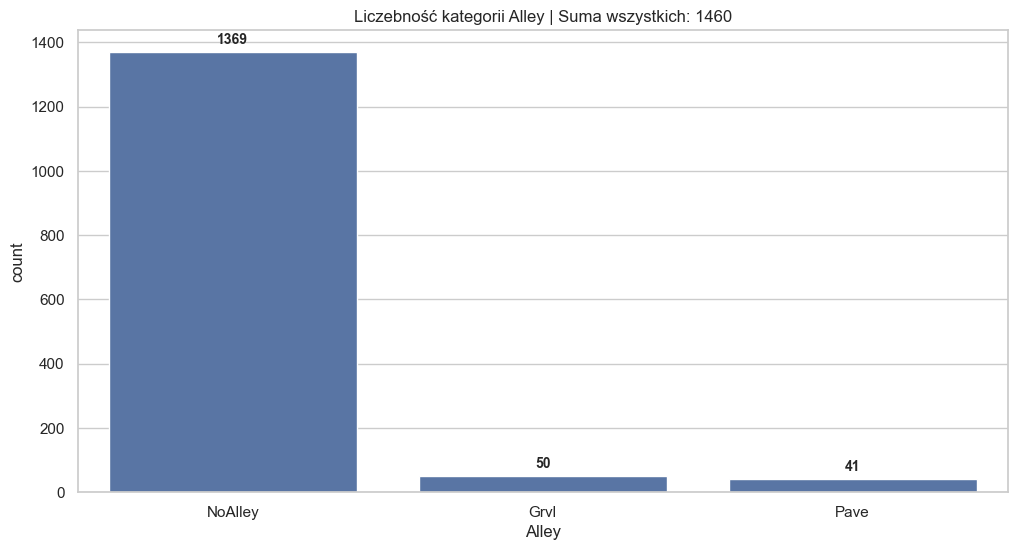

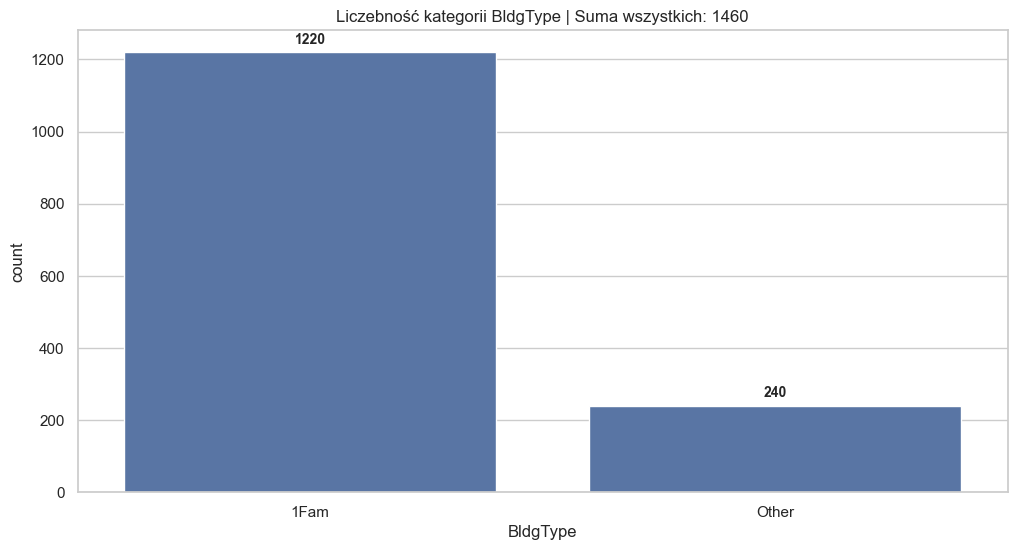

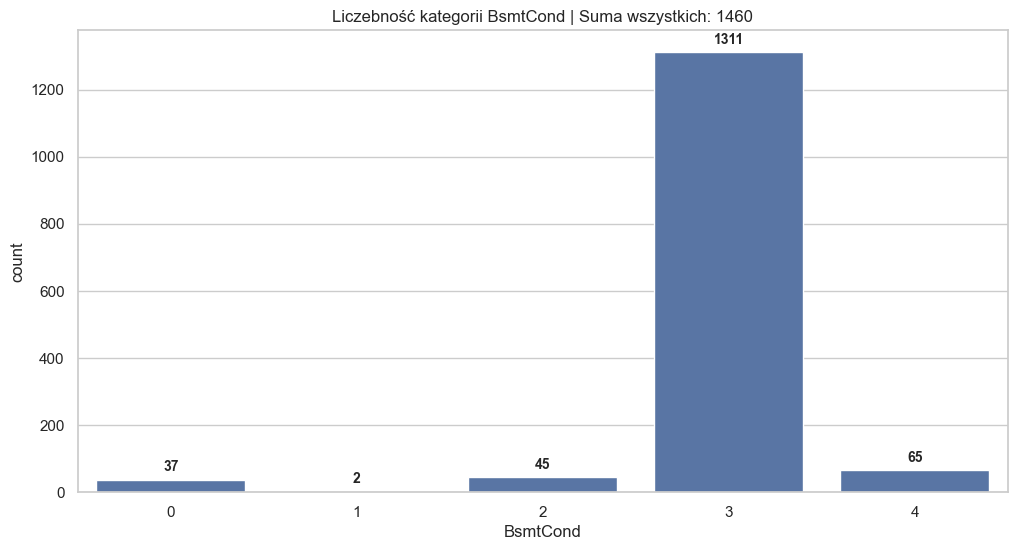

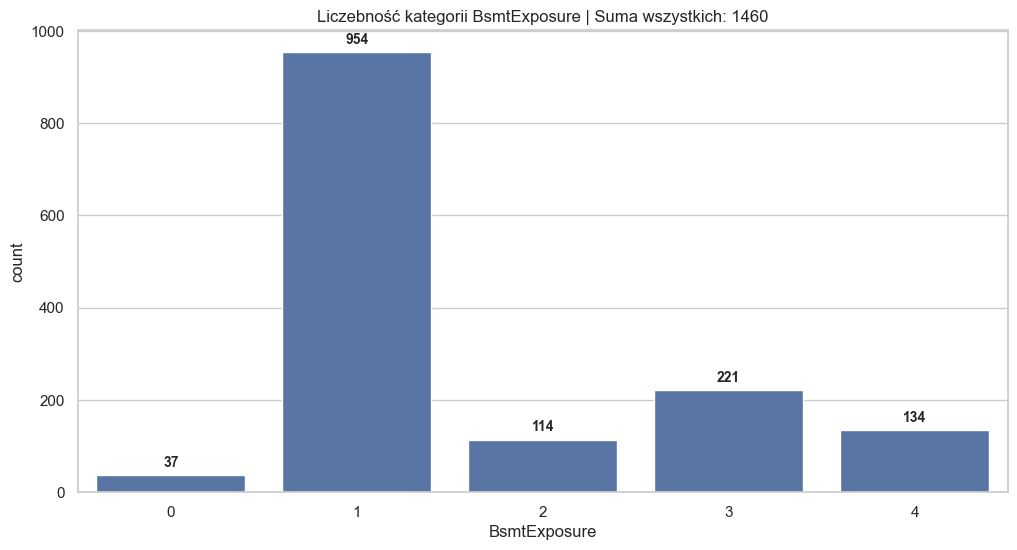

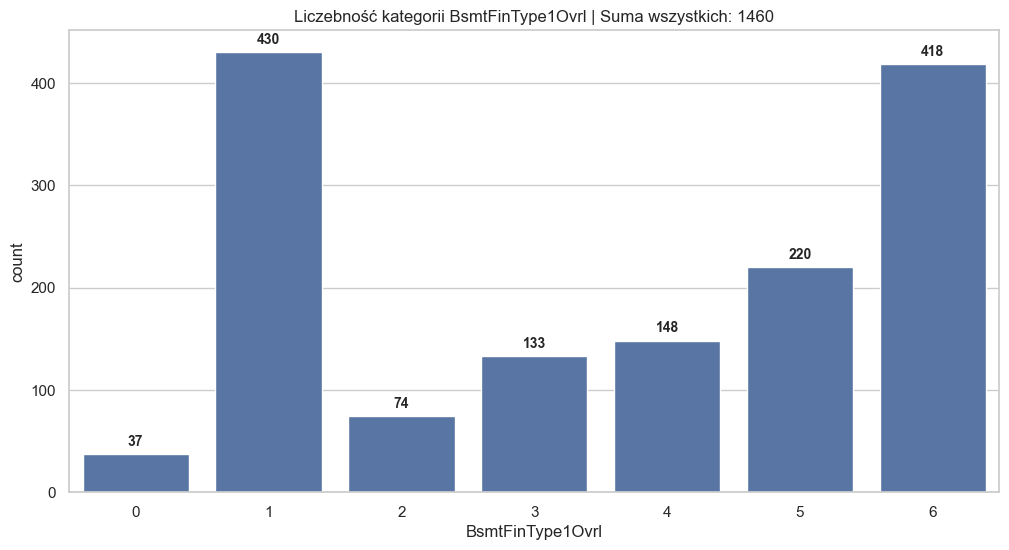

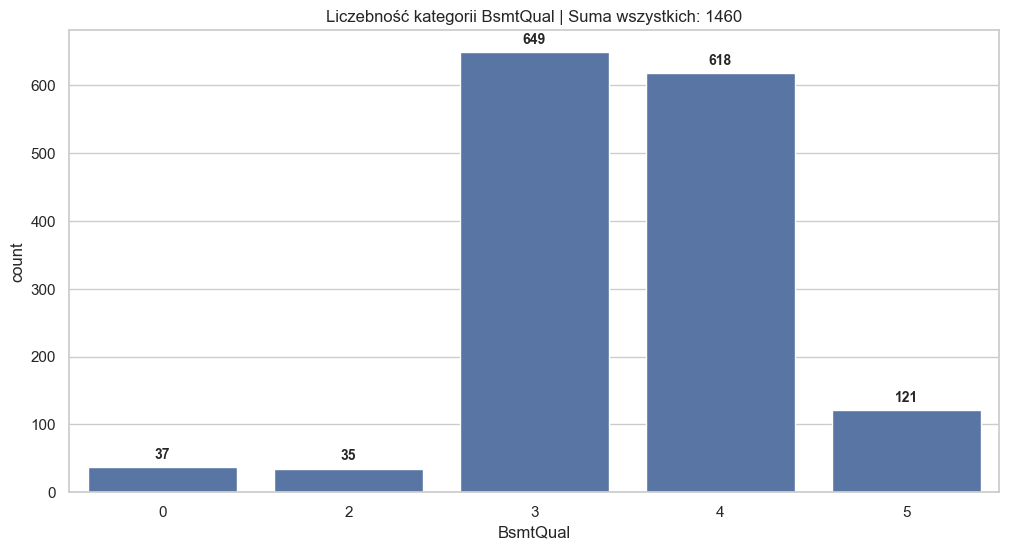

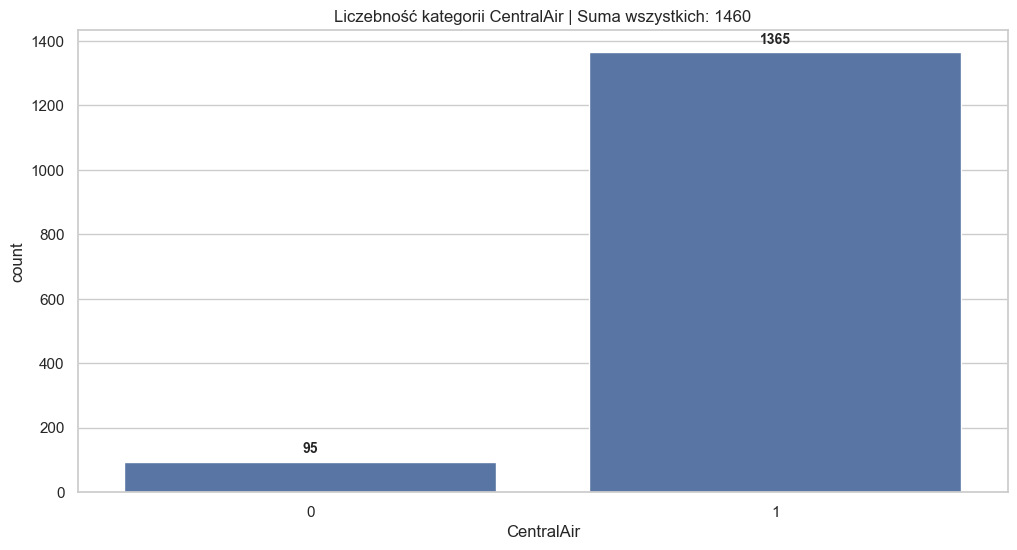

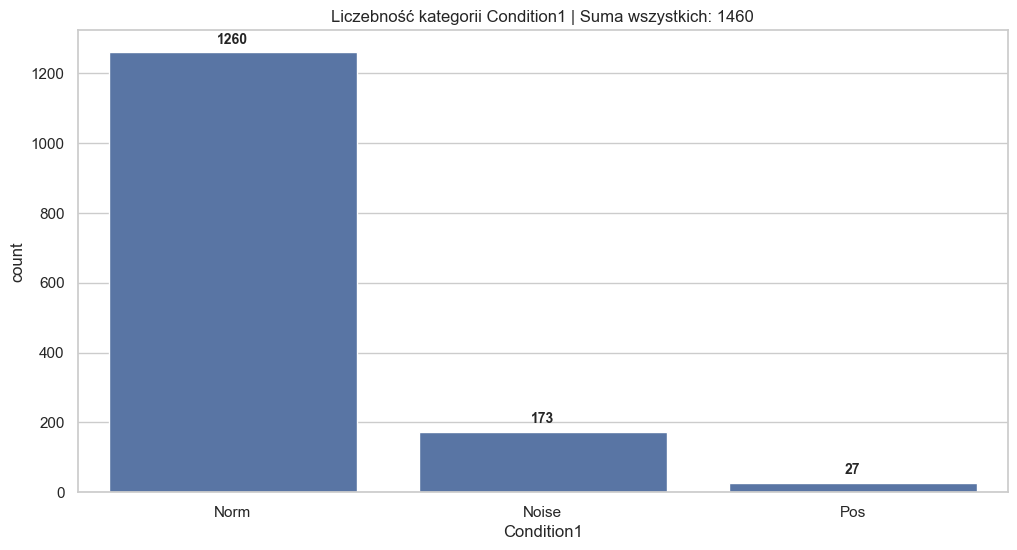

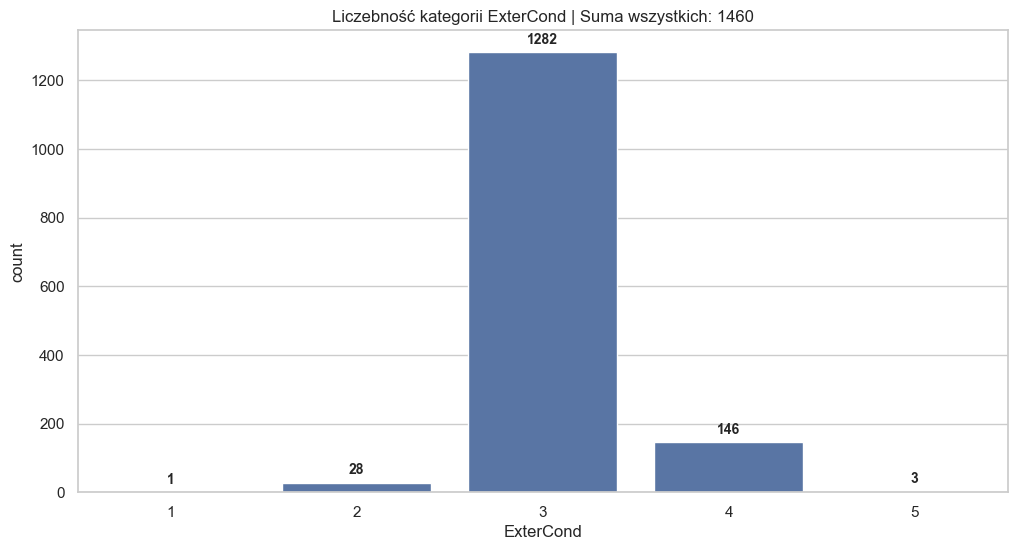

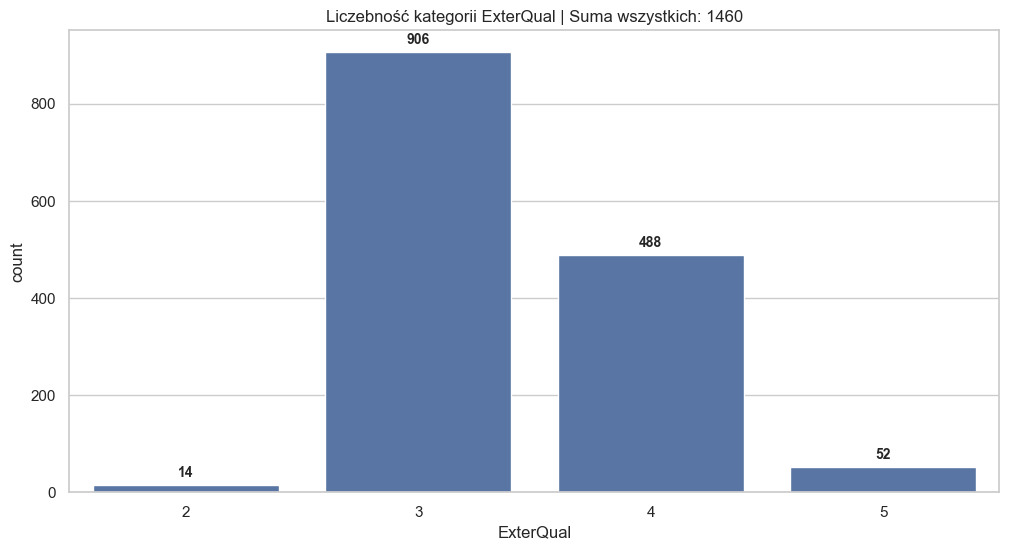

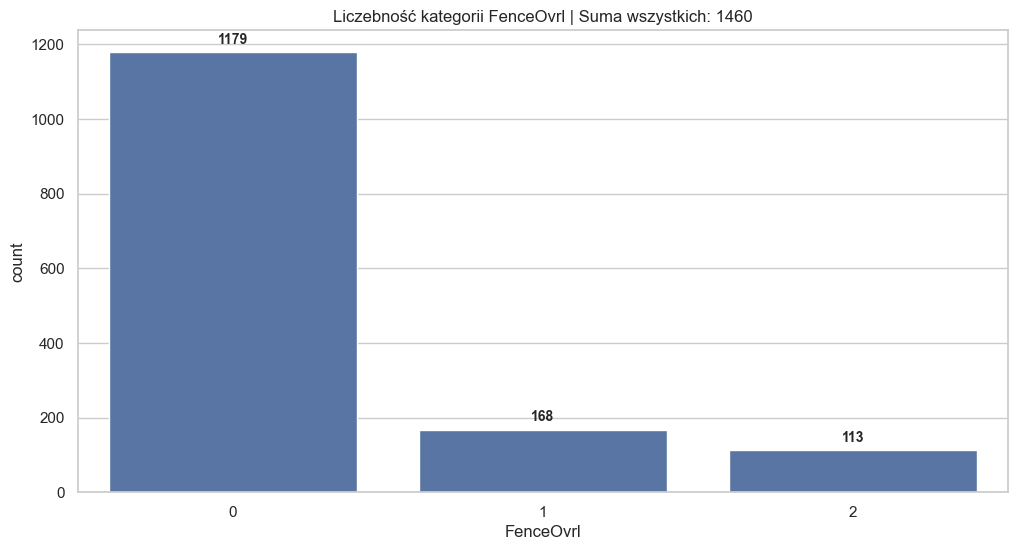

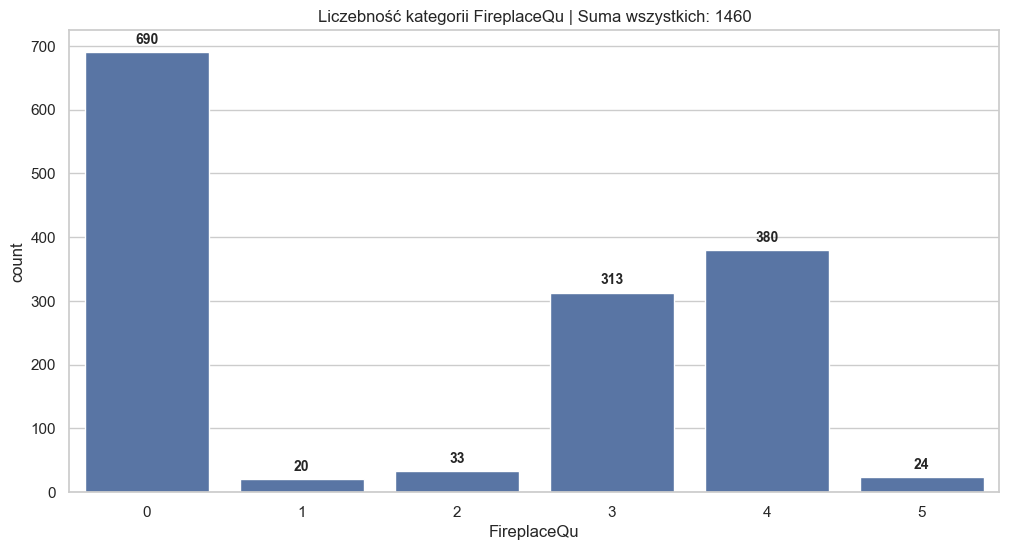

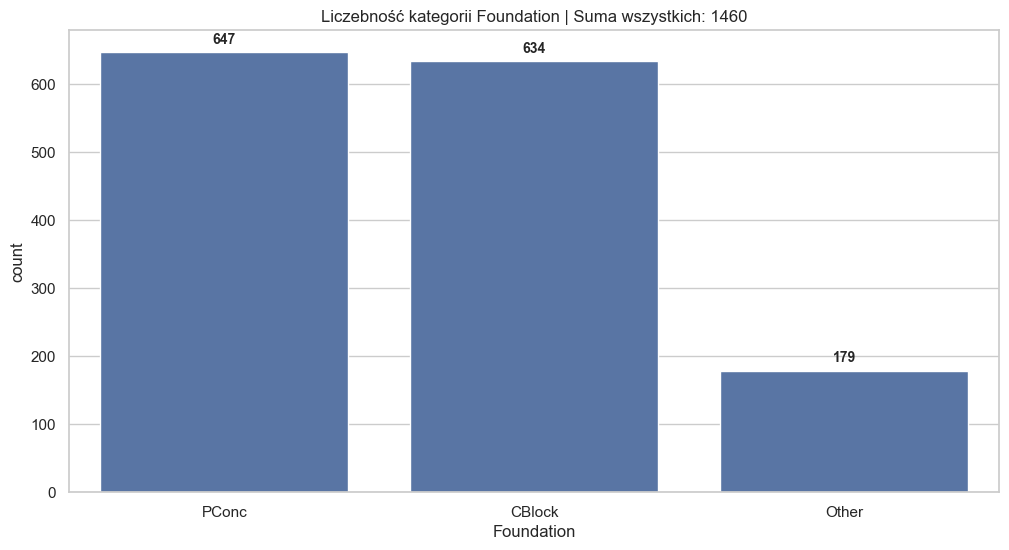

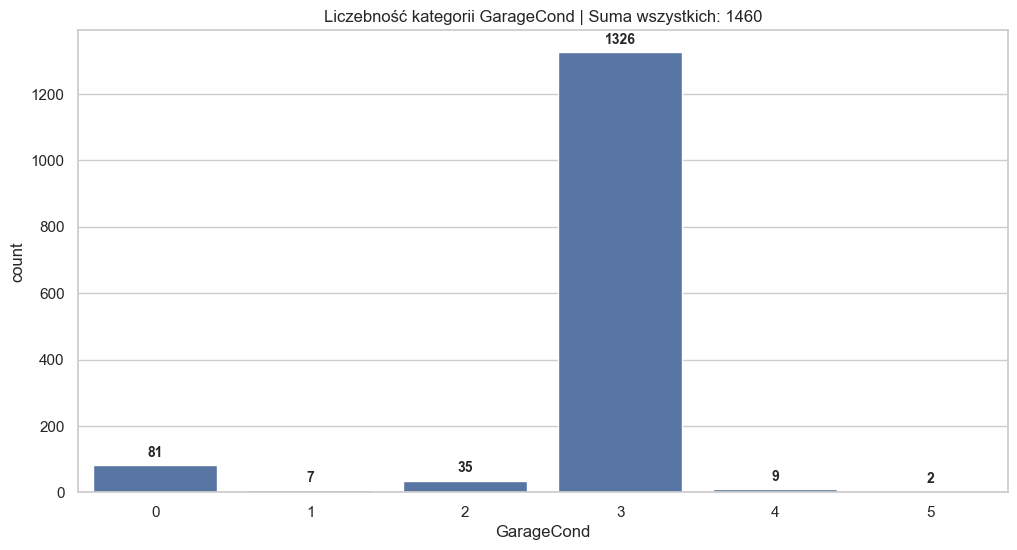

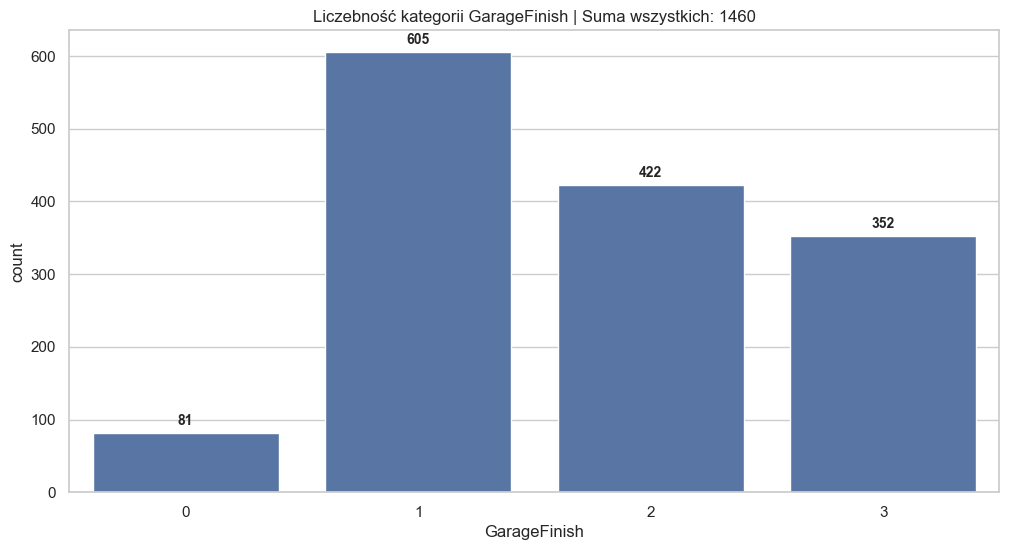

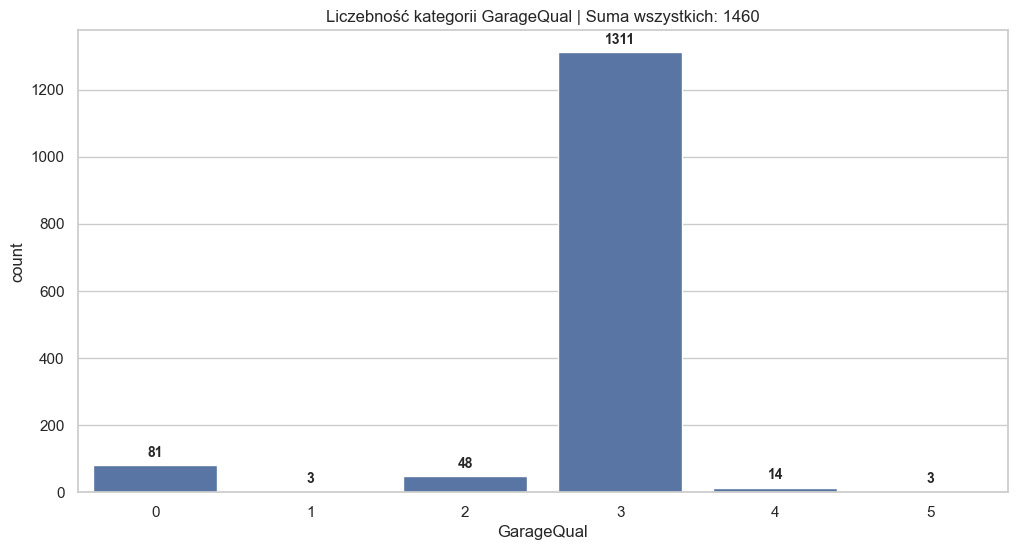

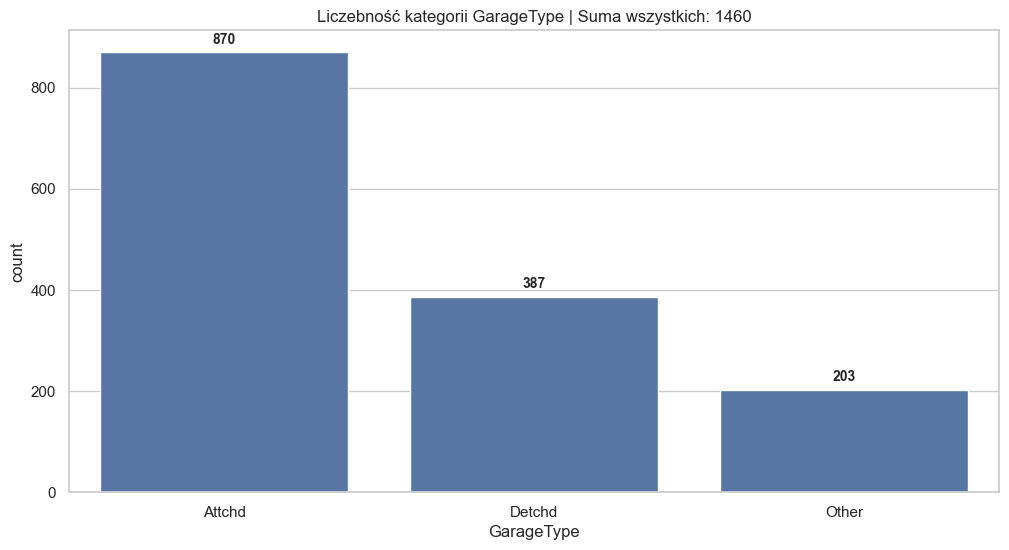

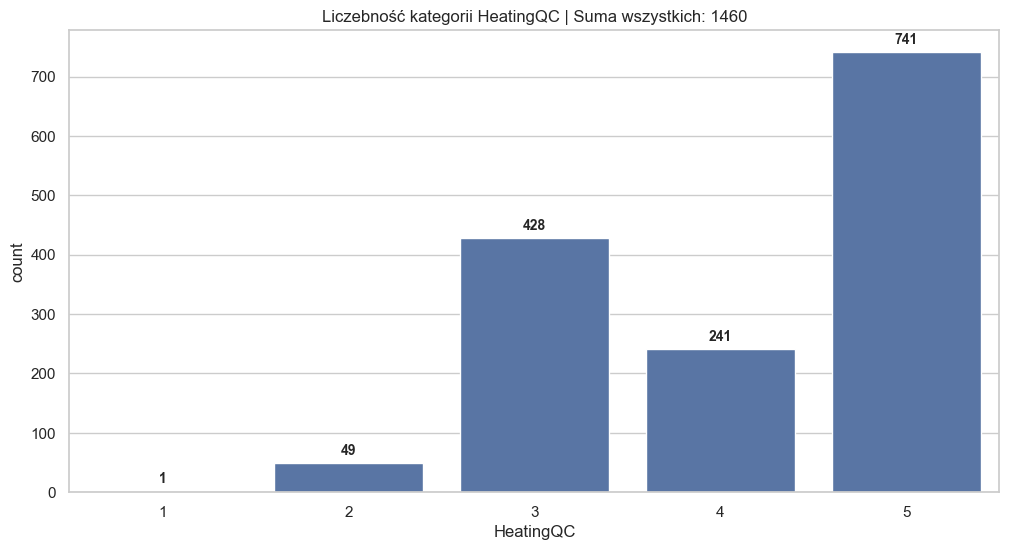

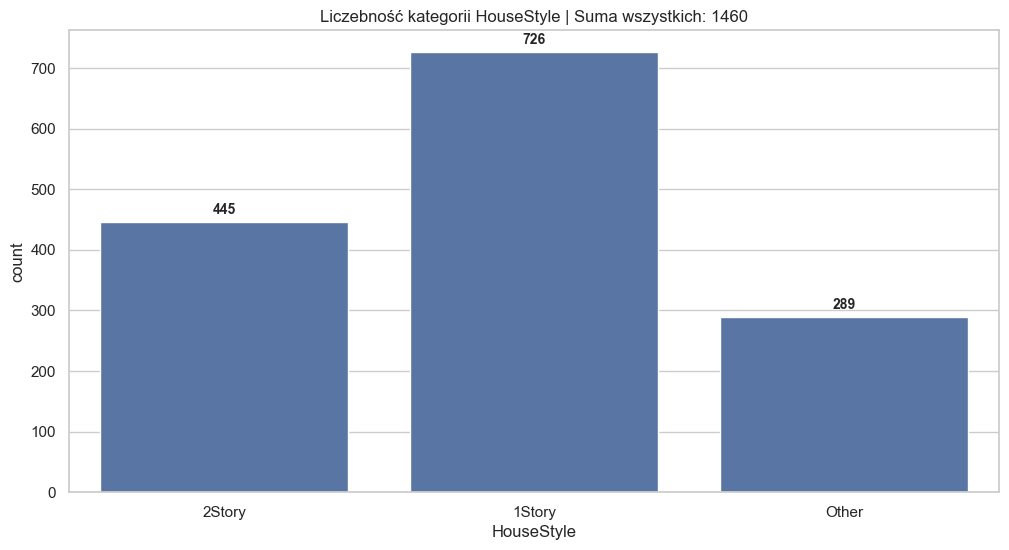

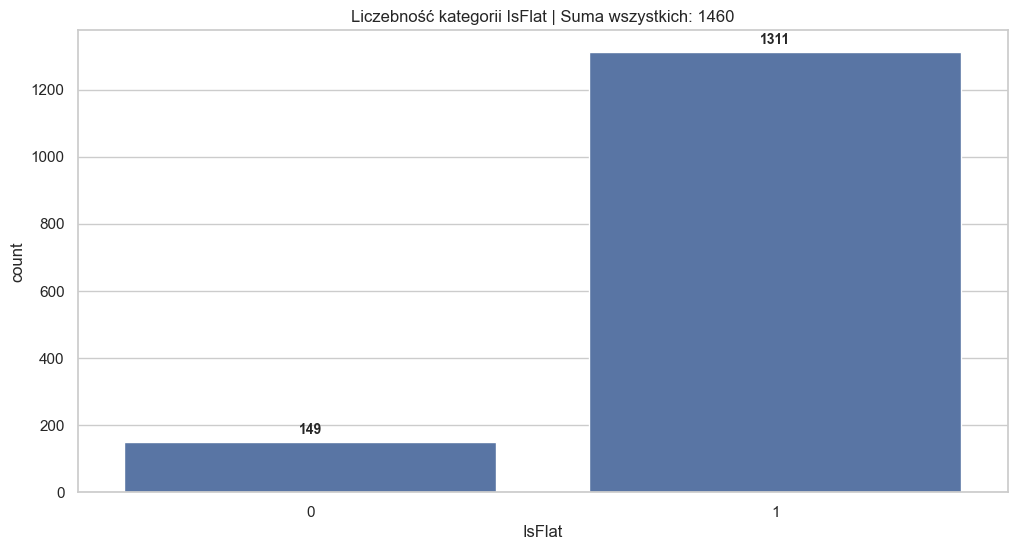

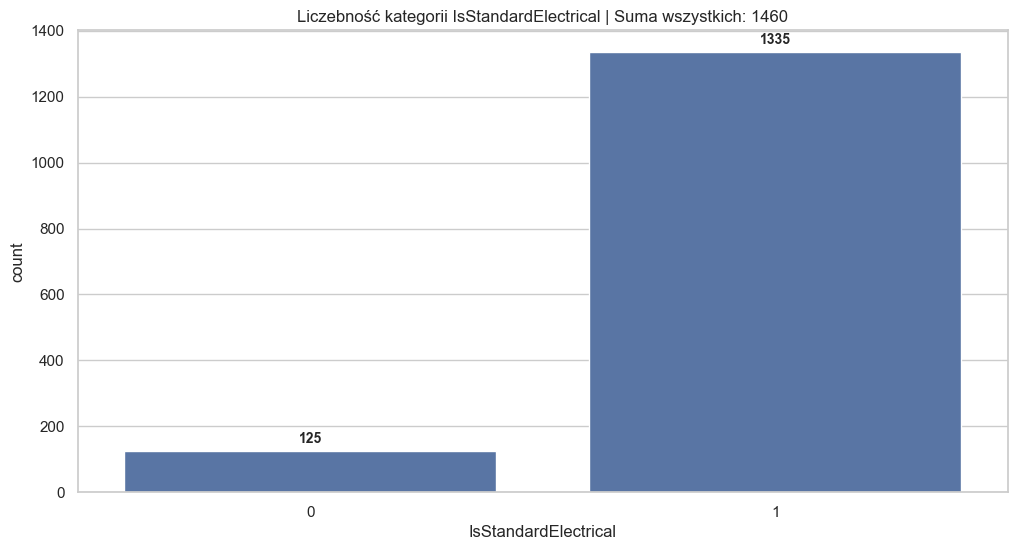

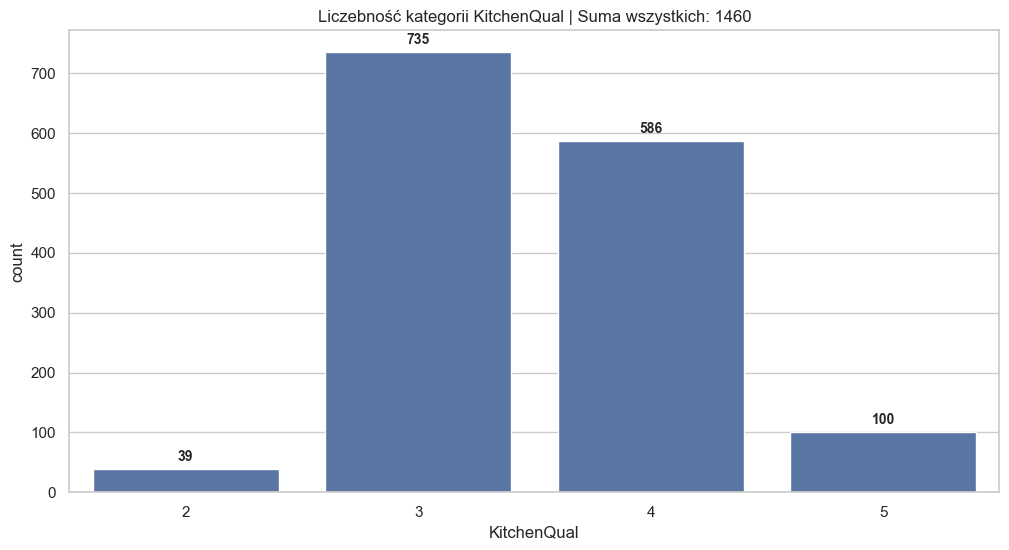

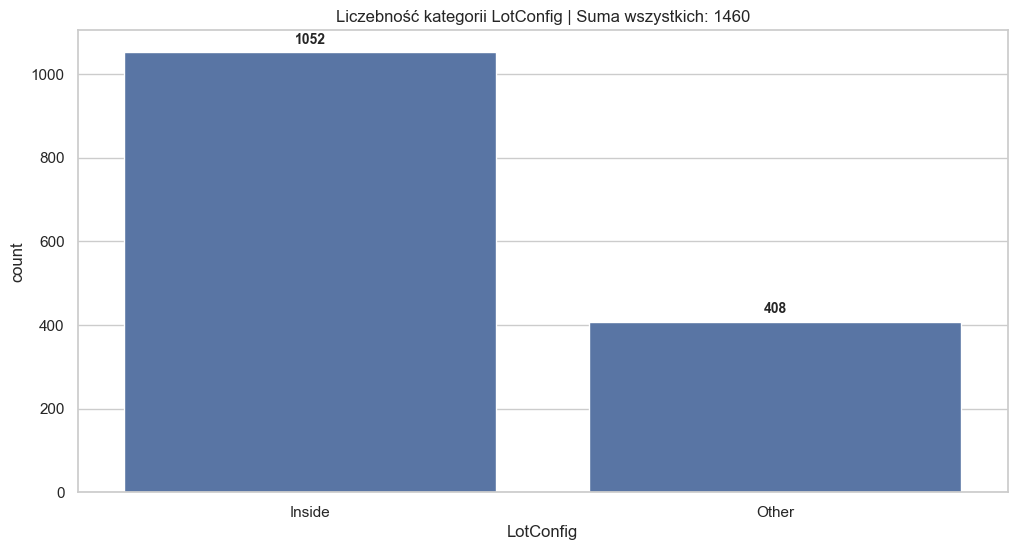

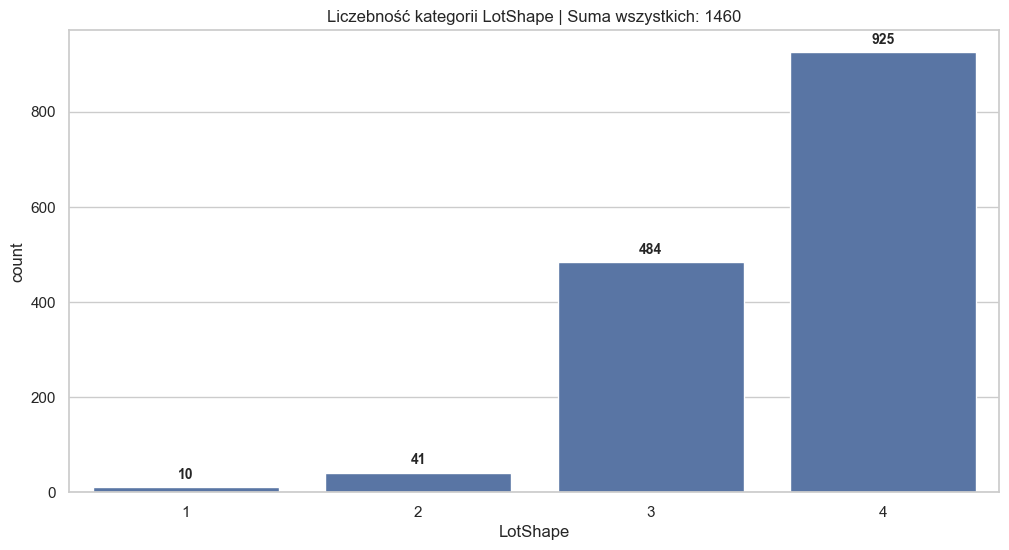

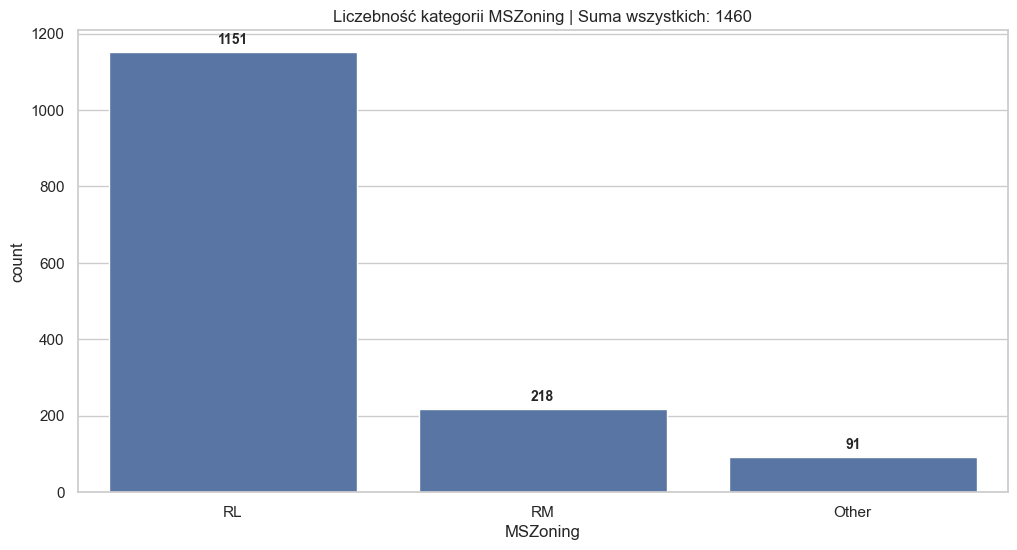

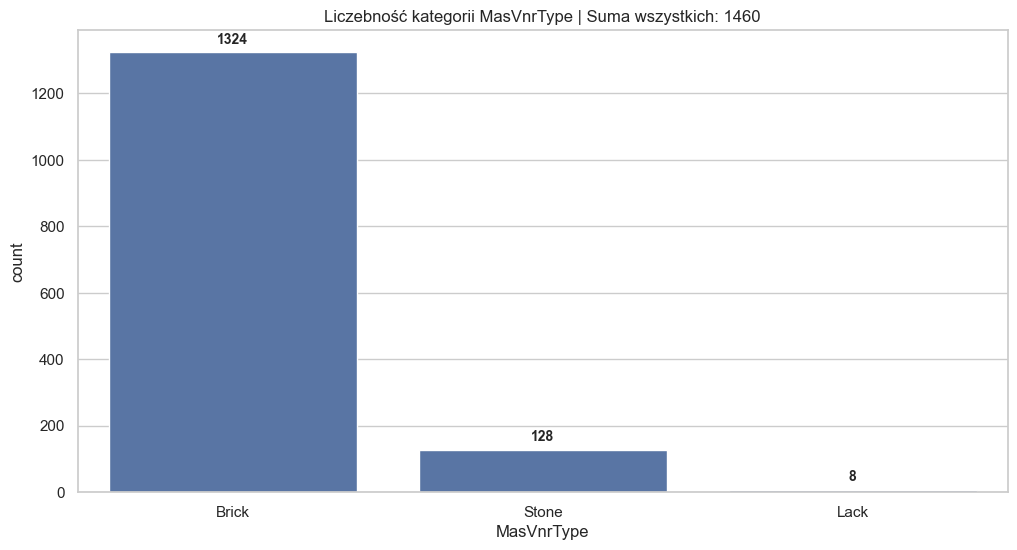

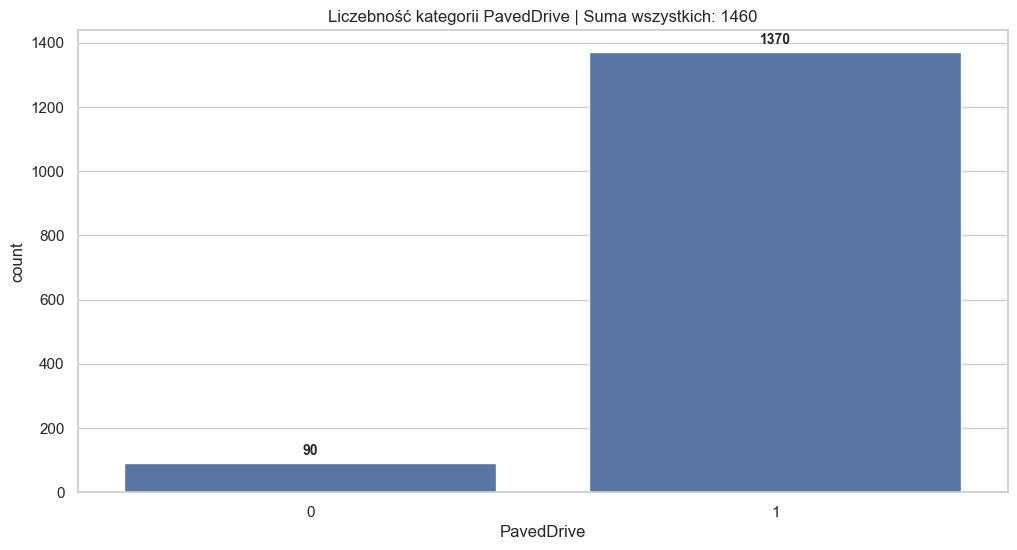

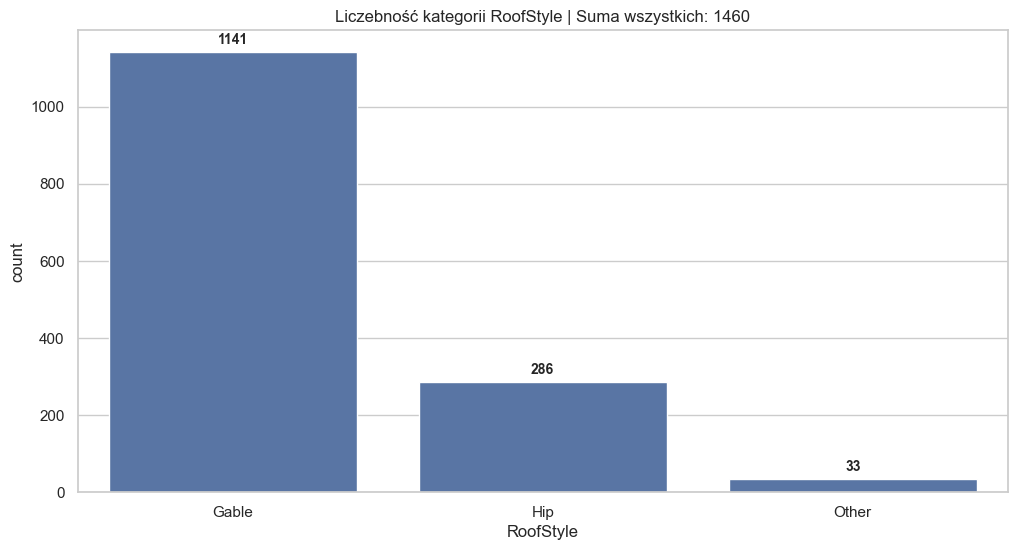

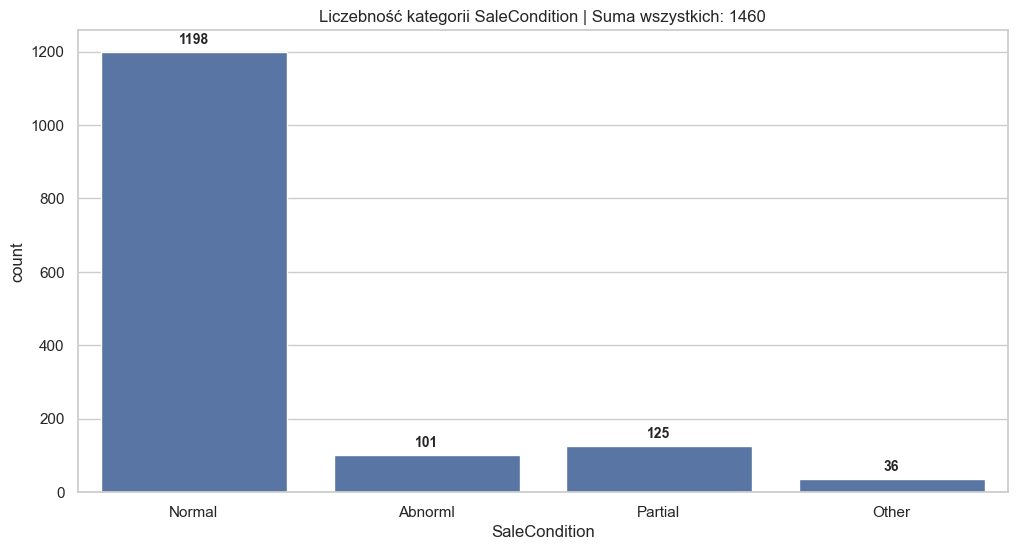

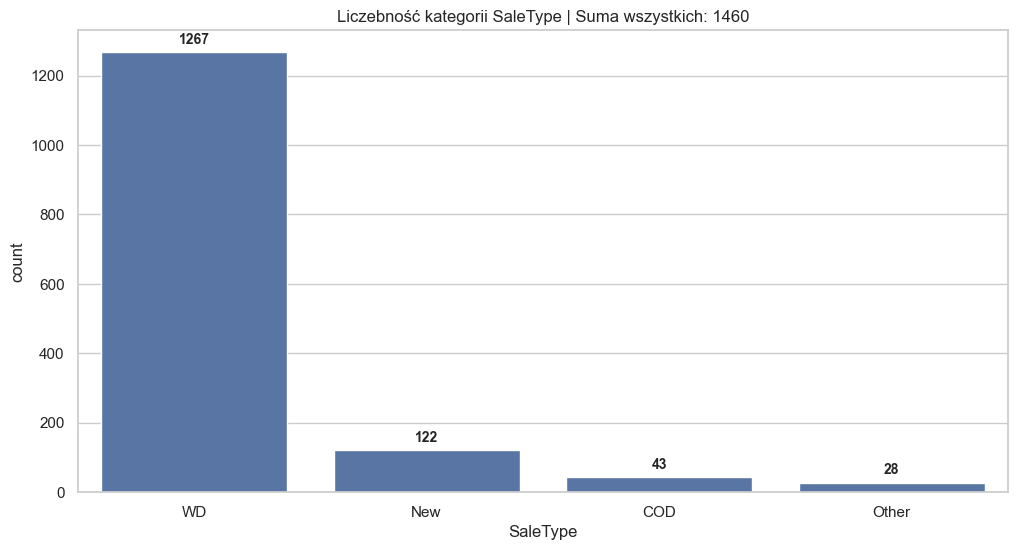

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_features_s = [col for col in cat_features_s if col in df.columns]
df_cat_s = df[cat_features_s]

df_cat_s = df_cat_s.sort_index(axis=1)

for col in df_cat_s.columns:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df_cat_s, x=col)
    
    # 1. Zliczenie sumy wszystkich słupków na danym wykresie
    total_count = sum(int(p.get_height()) for p in ax.patches)
    
    # Dodawanie liczb nad słupkami
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(format(height, '.0f'), 
                       (p.get_x() + p.get_width() / 2., height), 
                       ha='center', va='center', 
                       xytext=(0, 9), 
                       textcoords='offset points',
                       fontsize=10,
                       fontweight='bold')
    
    # 2. Wyświetlenie sumy w tytule za pomocą f-stringa
    plt.title(f"Liczebność kategorii {col} | Suma wszystkich: {total_count}")
    plt.show()

In [44]:
for col in df:
    if df[col].dtype == 'str':
        print(col + ": " + str(df[col].dtype))

Alley: str
BldgType: str
Condition1: str
Exterior1st: str
Exterior2nd: str
Foundation: str
GarageType: str
HouseStyle: str
LotConfig: str
MSZoning: str
MasVnrType: str
Neighborhood: str
RoofStyle: str
SaleCondition: str
SaleType: str


In [45]:
kolumny_tekstowe = df.select_dtypes(include=['object', 'string']).columns.tolist()
kolumny_do_kodowania = [col for col in kolumny_tekstowe if col not in ['Exterior1st', 'Exterior2nd', 'Neighborhood']]

df = pd.get_dummies(df, columns=kolumny_do_kodowania, dtype=int)

In [46]:
ue = df.columns
for i in ue:
    print(i + " - ")

1stFlrSF - 
2ndFlrSF - 
3SsnPorch - 
BedroomAbvGr - 
BsmtCond - 
BsmtExposure - 
BsmtFinSF1 - 
BsmtFinSF2 - 
BsmtFinType1Ovrl - 
BsmtFullBath - 
BsmtHalfBath - 
BsmtQual - 
BsmtUnfSF - 
CentralAir - 
IsStandardElectrical - 
EnclosedPorch - 
ExterCond - 
ExterQual - 
Exterior1st - 
Exterior2nd - 
FenceOvrl - 
FireplaceQu - 
Fireplaces - 
FullBath - 
GarageArea - 
GarageCars - 
GarageCond - 
GarageFinish - 
GarageQual - 
GarageYrBlt - 
GrLivArea - 
HalfBath - 
HeatingQC - 
Id - 
KitchenAbvGr - 
KitchenQual - 
IsFlat - 
LotArea - 
LotFrontage - 
LotShape - 
LowQualFinSF - 
MSSubClass - 
MasVnrArea - 
MiscVal - 
MoSold - 
Neighborhood - 
OpenPorchSF - 
OverallCond - 
OverallQual - 
PavedDrive - 
PoolArea - 
SalePrice - 
ScreenPorch - 
TotRmsAbvGrd - 
TotalBsmtSF - 
WoodDeckSF - 
YearBuilt - 
YearRemodAdd - 
YrSold - 
Alley_Grvl - 
Alley_NoAlley - 
Alley_Pave - 
BldgType_1Fam - 
BldgType_Other - 
Condition1_Noise - 
Condition1_Norm - 
Condition1_Pos - 
Foundation_CBlock - 
Foundation_Other 

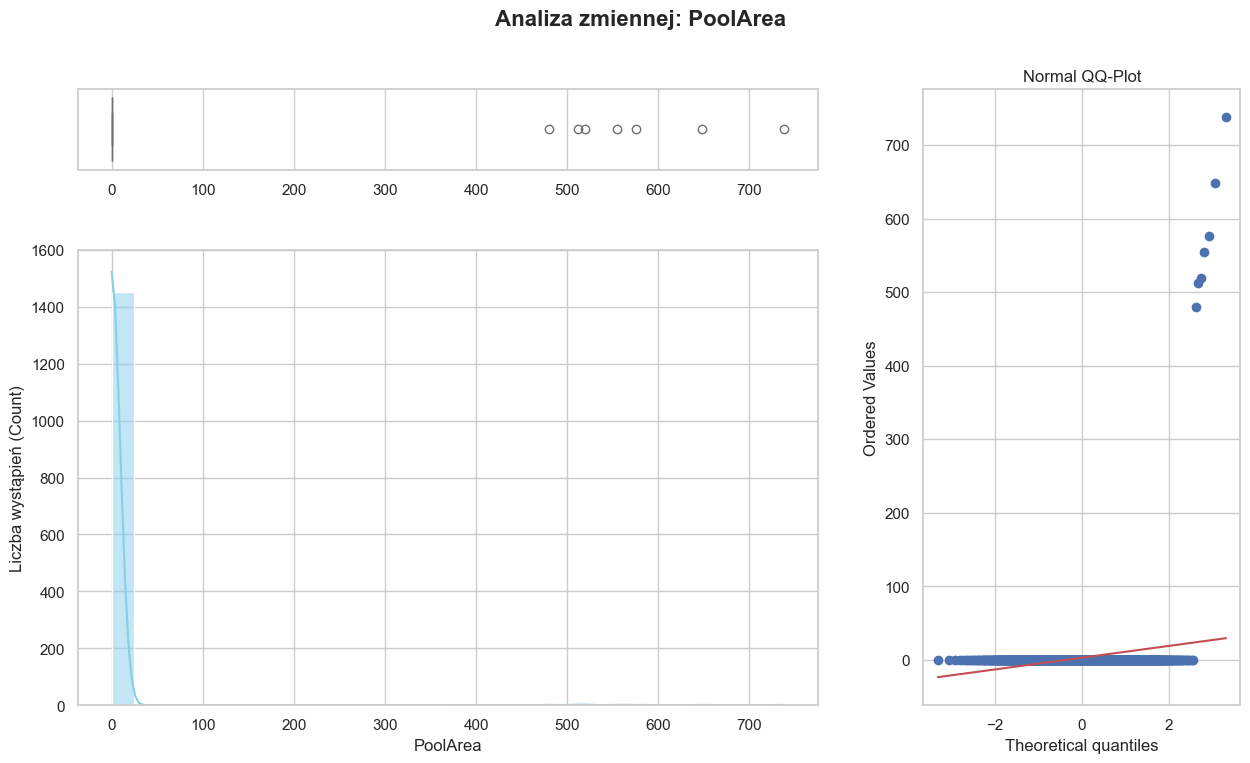

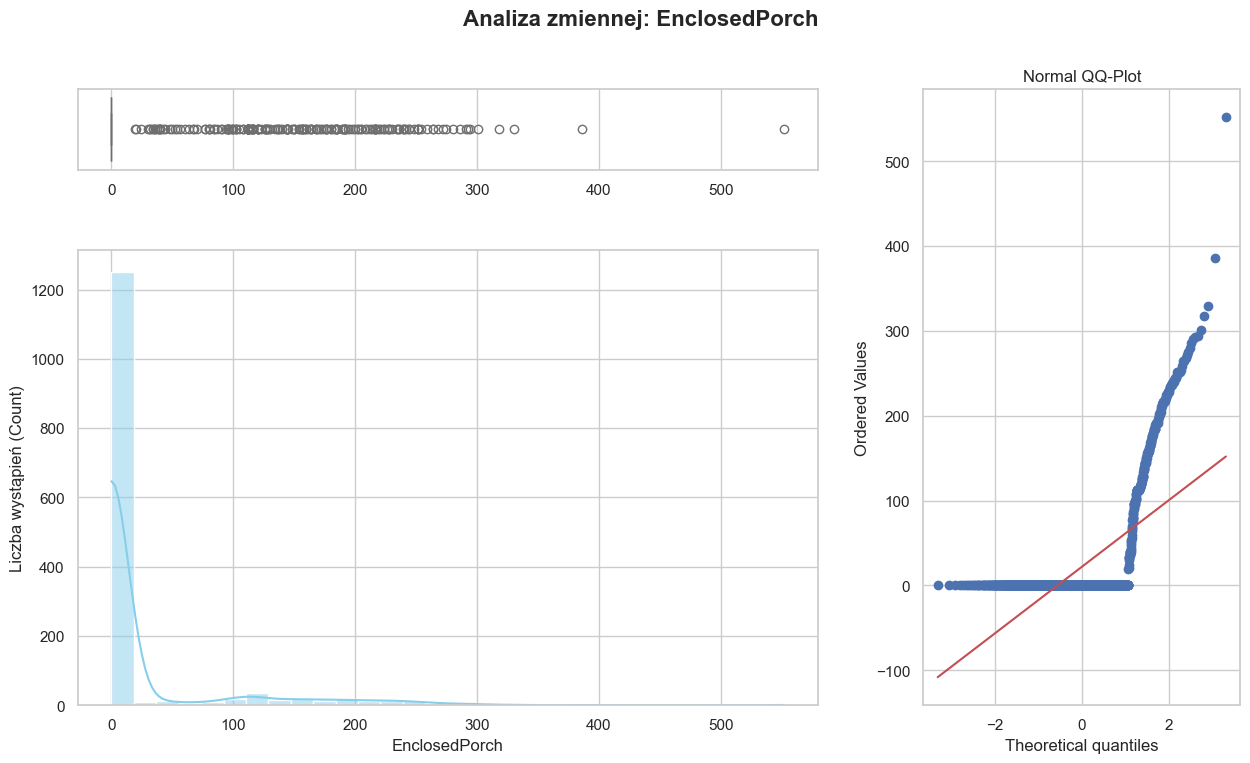

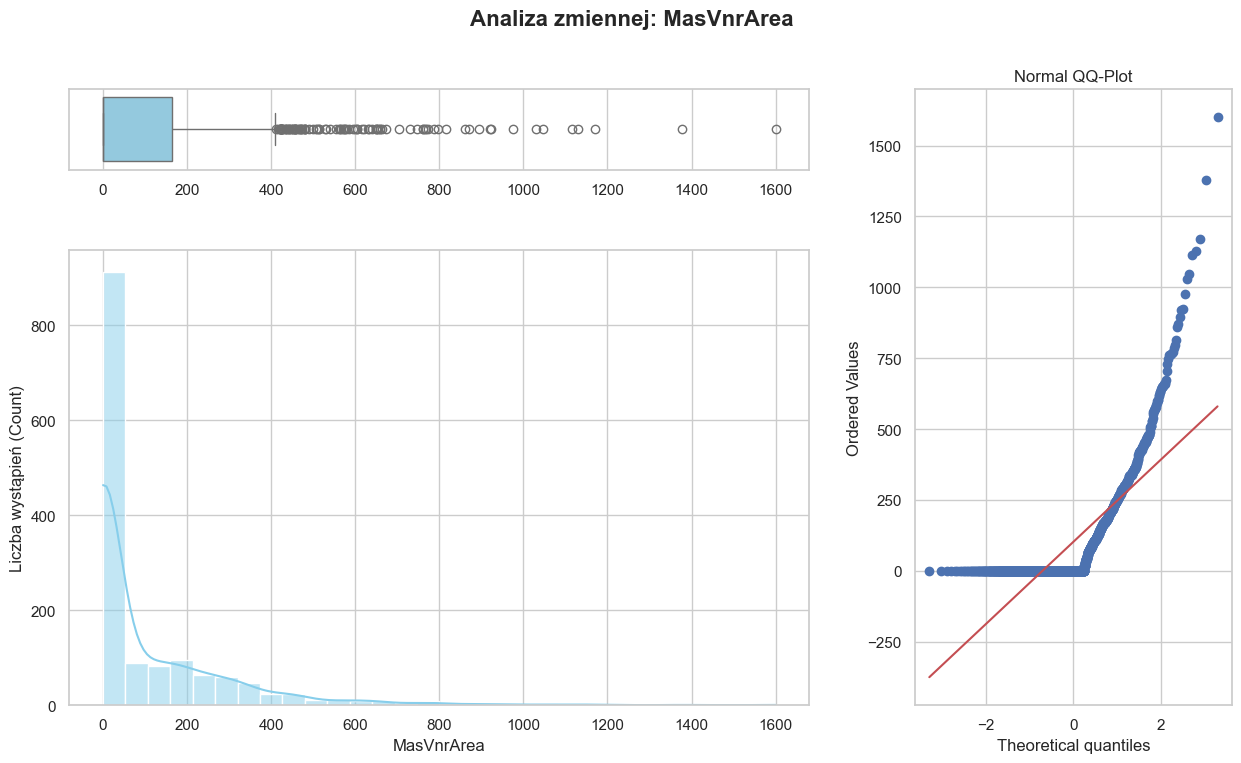

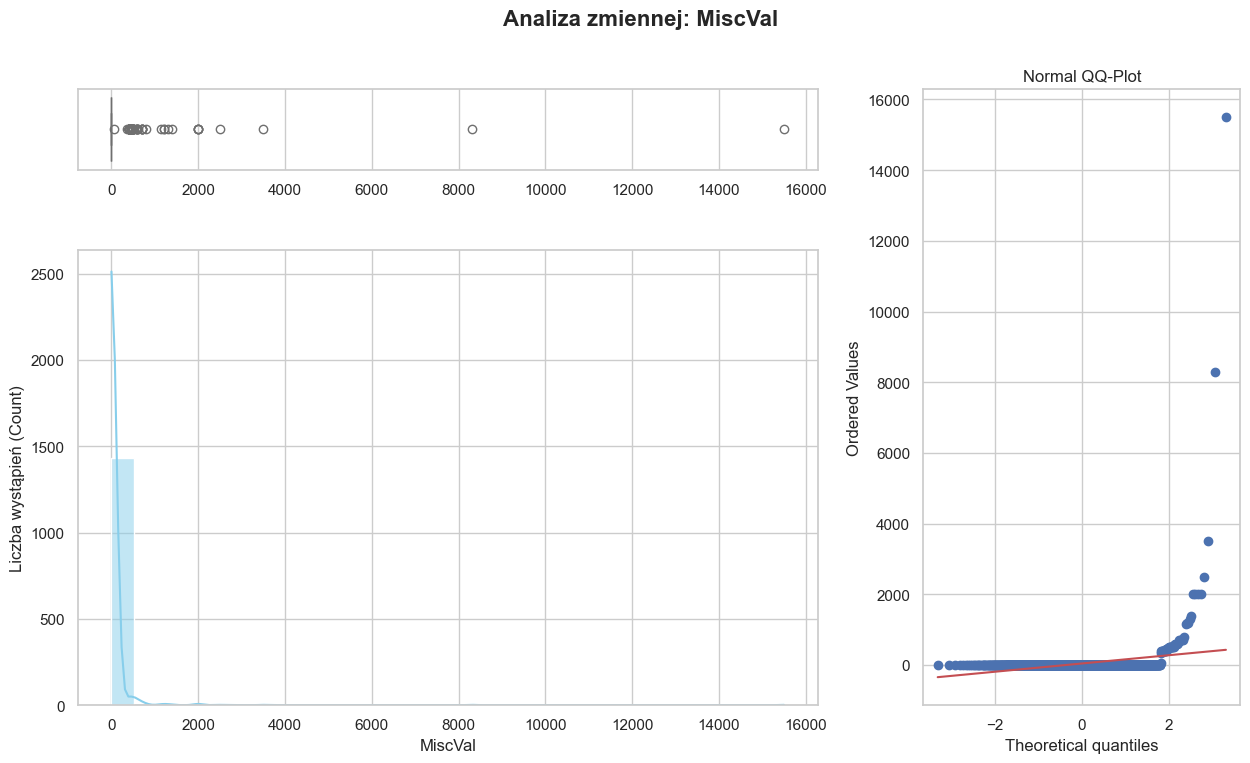

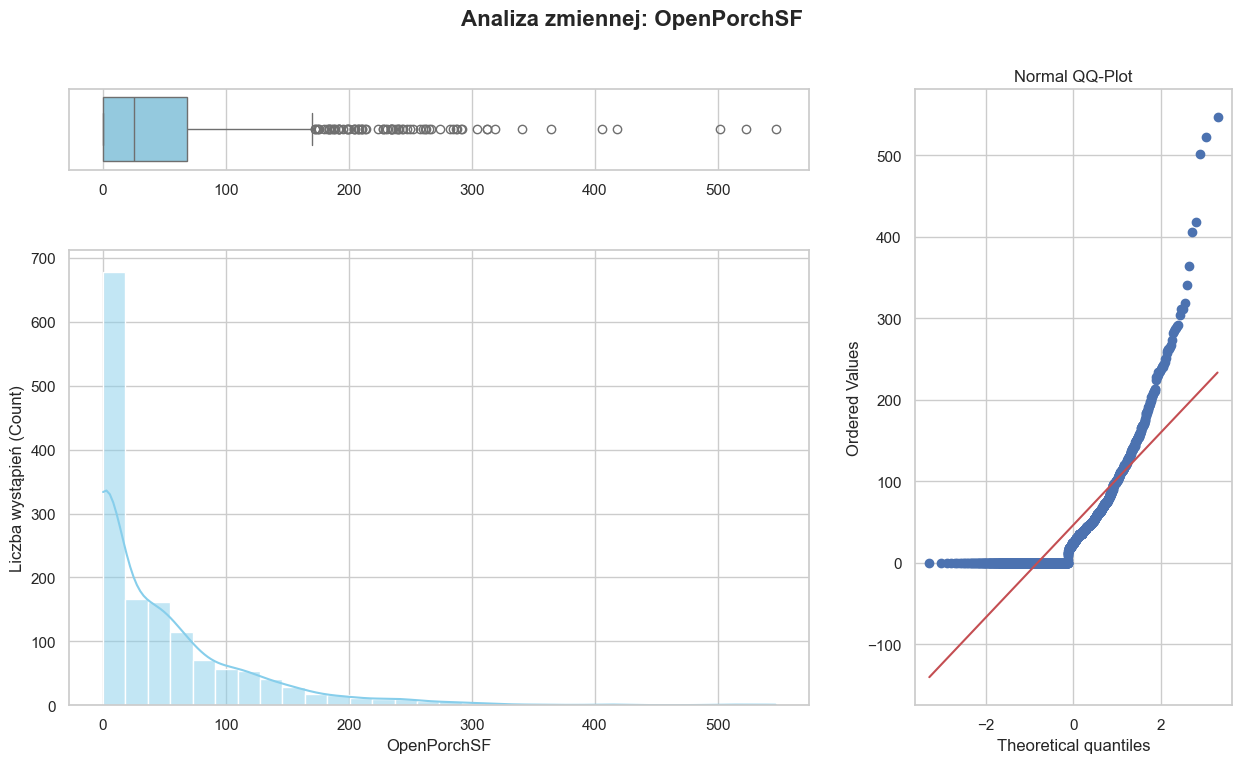

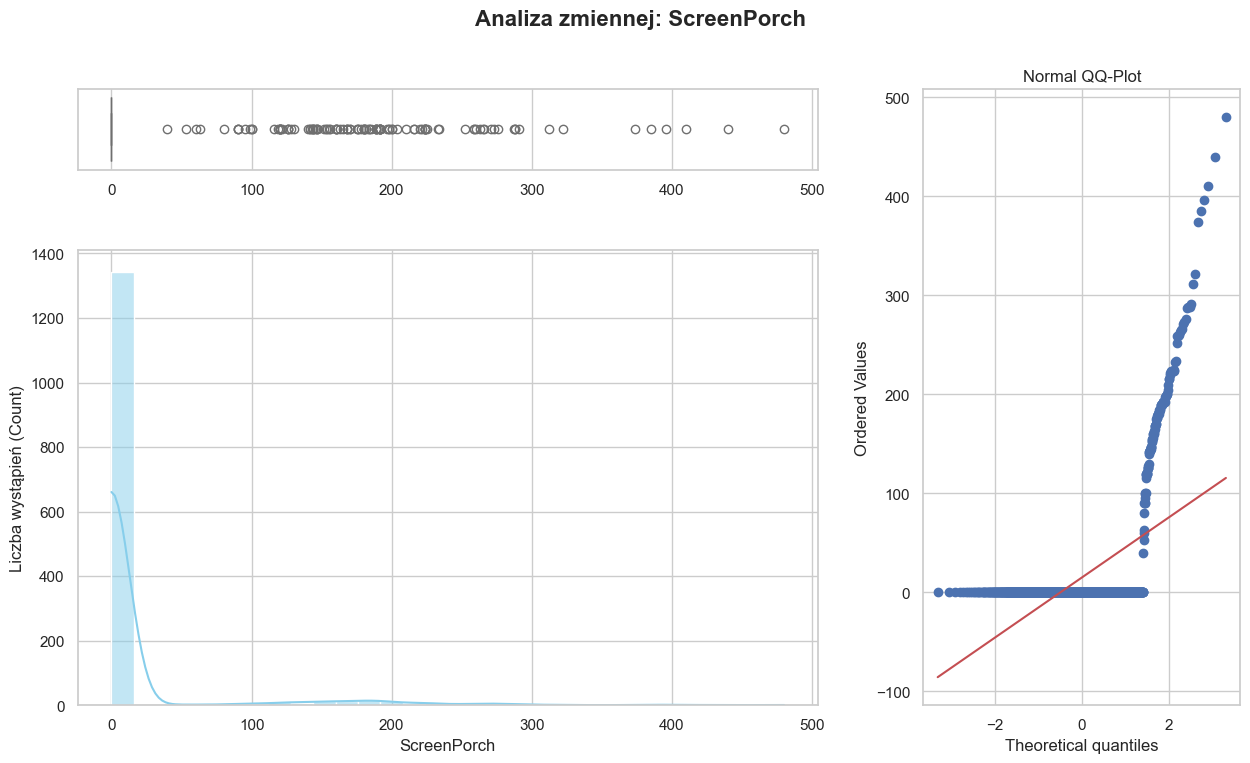

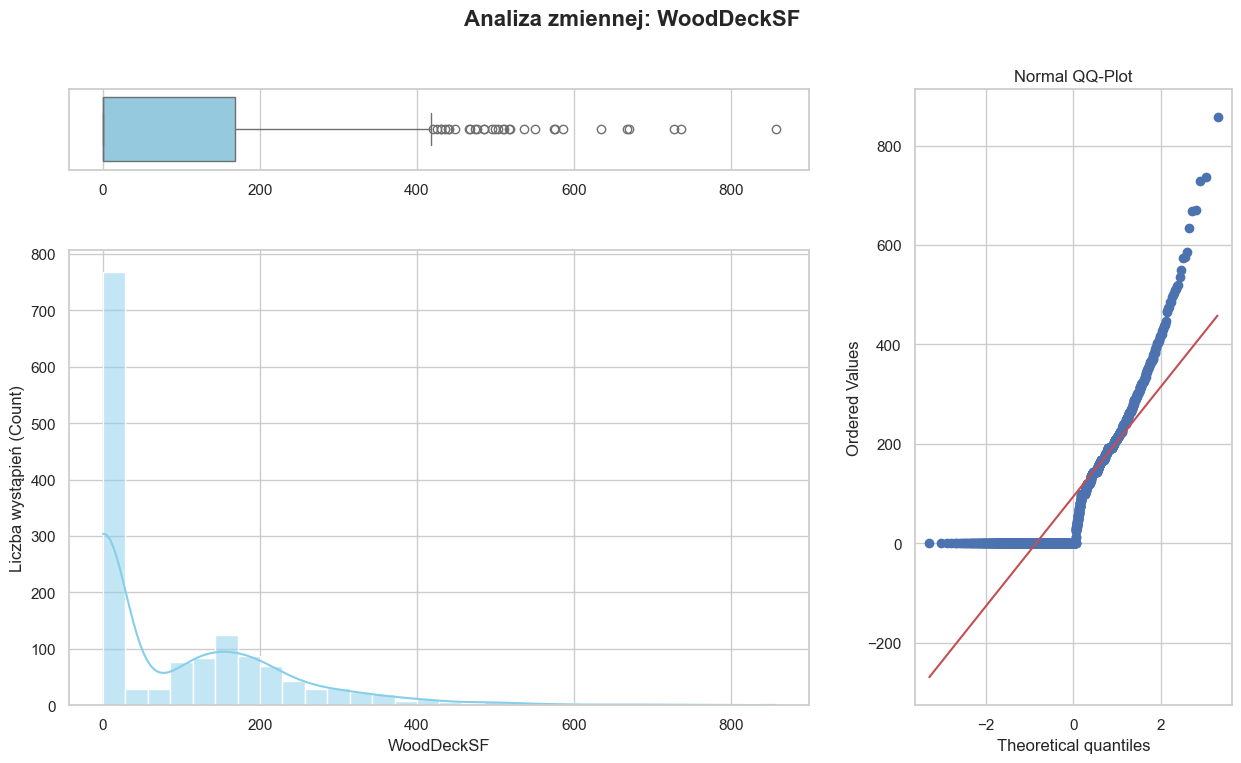

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid")

def plot_distributions(dataframe):
    numeric_cols = dataframe.select_dtypes(include=['number']).columns

    for col in numeric_cols:
    #for col in ['PoolArea', 'EnclosedPorch', 'MasVnrArea', 'MiscVal', 'OpenPorchSF', 'ScreenPorch', 'WoodDeckSF']:
        fig = plt.figure(figsize=(15, 8))
        grid = plt.GridSpec(2, 2, height_ratios=(.15, .85), width_ratios=(.7, .3), hspace=0.3, wspace=0.2)

        ax_box = fig.add_subplot(grid[0, 0], sharex=None)
        ax_hist = fig.add_subplot(grid[1, 0], sharex=ax_box)
        ax_qq = fig.add_subplot(grid[:, 1])

        # 1. Boxplot
        sns.boxplot(x=dataframe[col], ax=ax_box, color="skyblue")
        ax_box.set(xlabel='')
        
        # 2. Histplot
        sns.histplot(data=dataframe, x=col, ax=ax_hist, kde=True, bins=30, color="skyblue")
        ax_hist.set(ylabel='Liczba wystąpień (Count)')
        
        # 3. QQ-Plot
        stats.probplot(dataframe[col].dropna(), dist="norm", plot=ax_qq)
        ax_qq.set_title("Normal QQ-Plot")
        
        plt.suptitle(f'Analiza zmiennej: {col}', fontsize=16, fontweight='bold', y=0.98)
        plt.show()


df = df.sort_index(axis=1)
plot_distributions(df)

In [52]:
df['MiscVal'].value_counts(normalize=True)


MiscVal
0        0.964384
400      0.007534
500      0.005479
700      0.003425
450      0.002740
2000     0.002740
600      0.002740
480      0.001370
1200     0.001370
350      0.000685
15500    0.000685
800      0.000685
3500     0.000685
1300     0.000685
54       0.000685
620      0.000685
560      0.000685
1400     0.000685
8300     0.000685
1150     0.000685
2500     0.000685
Name: proportion, dtype: float64